# Phase 2: ML Model Training - Enhanced Multi-File Approach
**Objective:** Train a RandomForest classifier on larger, combined datasets for better anomaly detection accuracy

**What's New:** 
- Uses ALL available CSV files from `data/trainingFiles/` + `data/processed/anomaly_detection.csv`
- Combines multiple datasets for 10x+ training data
- Automatically handles different data formats
- Enhanced model with 200 trees instead of 100
- Real-time progress reporting

# Phase 2: RandomForest Model Training

**Objective**: Train a supervised ML model to enhance anomaly detection

**What we'll do**:
1. Load historical data (anomaly_detection.csv)
2. Engineer features from raw data
3. Train RandomForest classifier
4. Evaluate model performance
5. Visualize feature importance
6. Save model for production use

**Expected output**: `models/supervised_anomaly_model.pkl`

In [9]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  # Added for safety
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    roc_auc_score, precision_recall_curve
)
import joblib

# Add src to path to import custom modules
sys.path.insert(0, './src')
from train_ml_model import MLModelTrainer

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 1: Load Data

In [10]:
# Reload the training module to get the new method
import importlib
import train_ml_model
importlib.reload(train_ml_model)
print("✅ Module reloaded successfully!")

✅ Module reloaded successfully!


In [11]:
# ===== ENHANCED TRAINING: USE ALL AVAILABLE FILES =====
print("\n" + "="*70)
print("🚀 ENHANCED MULTI-FILE ML MODEL TRAINING")
print("="*70)

# Import the training manager
from train_ml_model import MLModelTrainer

# Create trainer instance
trainer = MLModelTrainer(model_dir="models/")

# Train using ALL available data (recommended)
success = trainer.train_on_all_available_data(force_retrain=True)

if success:
    print("\n✨ Model training successful!")
    print("   The model is now ready for use in the pipeline")
else:
    print("\n⚠️  Training failed. Check the errors above.")


🚀 ENHANCED MULTI-FILE ML MODEL TRAINING

PHASE 2: ENHANCED MULTI-FILE MODEL TRAINING

📂 Step 1: Collecting all available training files...

🔄 Combining all training files...

📊 TRAINING DATA COLLECTION REPORT

📂 Training Files Directory: data/trainingFiles
   Found: 4 CSV files

   ✅ cleaned_supermarket_dataset.csv
      Rows: 9,986 | Cols: 22 | Size: 2.3 MB
   ✅ cleaned_transactions_dataset.csv
      Rows: 12,575 | Cols: 12 | Size: 1.2 MB
   ✅ dirty_multicell_supermarket_dataset.csv
      Rows: 9,986 | Cols: 22 | Size: 2.3 MB
   ✅ dirty_transactions_dataset.csv
      Rows: 12,575 | Cols: 12 | Size: 1.2 MB

   ✅ anomaly_detection.csv (LARGE DATASET)
      Rows: 242 | Cols: 20 | Size: 0.0 MB

📈 SUMMARY
   Total training files: 5
   Total rows available: 45,364

   Loading anomaly_detection.csv...
      ✓ Loaded 242 rows
   Loading cleaned_supermarket_dataset.csv...
      ✓ Loaded 9,986 rows
   Loading cleaned_transactions_dataset.csv...
      ✓ Loaded 12,575 rows
   Loading dirty_multi

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.7s finished


   ✓ Training complete!

📊 Top 15 Most Important Features:
    1. price_is_zero                  0.3887
    2. price_value                    0.3490
    3. price_per_unit_variance        0.1719
    4. category_encoded               0.0534
    5. quantity_is_zero               0.0220
    6. quantity_value                 0.0098
    7. price_qty_interaction          0.0053
    8. price_is_negative              0.0000
    9. quantity_is_negative           0.0000

💾 Saving enhanced model...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


   ✓ Model saved: models/supervised_anomaly_model.pkl
   ✓ Encoders saved: models/feature_encoders.pkl
   ✓ Feature names saved: models/feature_names.json
   ✓ Metadata saved: models/enhanced_model_metadata.json

✅ PHASE 2 ENHANCED TRAINING COMPLETE
Training rows: 45,342
Features engineered: 9
Model accuracy: 50.24%
Trees: 200 | Max Depth: 20

🎯 Ready for production use!


✨ Model training successful!
   The model is now ready for use in the pipeline


[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished


In [12]:
# Load combined balanced training data (50% anomalies, 50% normal)
from training_data_manager import TrainingDataManager

print(f"📂 Loading combined balanced training data...")
manager = TrainingDataManager()
df = manager.combine_training_files()

print(f"✅ Data loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

# Display first few rows
print("\n📋 First 5 rows:")
display(df.head())

# Display column info
print("\n📊 Column information:")
print(df.info())


📂 Loading combined balanced training data...

🔄 Combining all training files...

📊 TRAINING DATA COLLECTION REPORT

📂 Training Files Directory: data/trainingFiles
   Found: 4 CSV files

   ✅ cleaned_supermarket_dataset.csv
      Rows: 9,986 | Cols: 22 | Size: 2.3 MB
   ✅ cleaned_transactions_dataset.csv
      Rows: 12,575 | Cols: 12 | Size: 1.2 MB
   ✅ dirty_multicell_supermarket_dataset.csv
      Rows: 9,986 | Cols: 22 | Size: 2.3 MB
   ✅ dirty_transactions_dataset.csv
      Rows: 12,575 | Cols: 12 | Size: 1.2 MB

   ✅ anomaly_detection.csv (LARGE DATASET)
      Rows: 242 | Cols: 20 | Size: 0.0 MB

📈 SUMMARY
   Total training files: 5
   Total rows available: 45,364

   Loading anomaly_detection.csv...
      ✓ Loaded 242 rows
   Loading cleaned_supermarket_dataset.csv...
      ✓ Loaded 9,986 rows
   Loading cleaned_transactions_dataset.csv...
      ✓ Loaded 12,575 rows
   Loading dirty_multicell_supermarket_dataset.csv...
      ✓ Loaded 9,986 rows
   Loading dirty_transactions_dataset

,sale_id,product,category,price,quantity,total,date,store,city,has_anomaly,...,Discount,Profit,Transaction ID,Item,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,NaN,Chicken,Dry,32.28,0.0,NaN,NaN,Carrefour,Sousse,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,Pasta,Dry,23.11,0.0,error,2022-01-28,NaN,Tunis,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,Rice,Fruits,29.09,0.0,0.0,NaN,Monoprix,Sfax,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,Milk,Fruits,45.79,0.0,-100,NaN,MG,Tunis,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,Rice,Meat,36.28,0.0,-100,NaN,Monoprix,Tunis,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



📊 Column information:
<class 'pandas.core.frame.DataFrame'>
Index: 45342 entries, 0 to 45363
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sale_id             195 non-null    float64
 1   product             220 non-null    object 
 2   category            181 non-null    object 
 3   price               220 non-null    float64
 4   quantity            220 non-null    float64
 5   total               170 non-null    object 
 6   date                59 non-null     object 
 7   store               177 non-null    object 
 8   city                220 non-null    object 
 9   has_anomaly         45342 non-null  bool   
 10  anomaly_types       220 non-null    object 
 11  anomaly_flags       220 non-null    float64
 12  anomaly_severity    220 non-null    object 
 13  anomaly_score       220 non-null    float64
 14  empty_count         220 non-null    float64
 15  severity_weight     220 non-null   

## Step 1B: Load Multiple CSV Files (Enhanced Training)

In [13]:
# This cell is redundant - data already loaded from cell 7 above
# Skip this cell - use df from combined training files loaded above
print("ℹ️  Data already loaded in previous cell from TrainingDataManager")
print(f"Using df with shape: {df.shape}")
print(f"Classes: Anomalies={( df['has_anomaly'] == True).sum()}, Normal={( df['has_anomaly'] == False).sum()}")


ℹ️  Data already loaded in previous cell from TrainingDataManager
Using df with shape: (45342, 49)
Classes: Anomalies=22781, Normal=22561


## Step 2: Prepare Target Variable

In [14]:
# Prepare target variable - PRIORITIZE has_anomaly from balanced training data
print("🎯 Preparing target variable...\\n")

# CHECK has_anomaly FIRST (our balanced column)
if 'has_anomaly' in df.columns:
    # has_anomaly: True=anomaly, False=normal → 1=anomaly, 0=normal
    target = df['has_anomaly'].astype(int)
    print("✅ Using 'has_anomaly' column from balanced training data")
elif 'anomaly' in df.columns:
    # anomaly: 1=normal, -1=anomaly
    target = (df['anomaly'] == 1).astype(int)
    print("✅ Using 'anomaly' column from data")
else:
    print("⚠️  Creating synthetic labels...")
    if 'anomaly_flags' in df.columns:
        target = (df['anomaly_flags'] == 0).astype(int)
    else:
        raise ValueError("Cannot determine target variable!")

print(f"\\nTarget distribution:")
print(f"  Anomaly (1): {(target == 1).sum()} rows ({(target == 1).mean()*100:.1f}%)")
print(f"  Normal (0): {(target == 0).sum()} rows ({(target == 0).mean()*100:.1f}%)")

# Prepare features using trainer
print("\\n🔧 Engineering features using MLModelTrainer...\\n")
trainer = MLModelTrainer(model_dir='models/')
features = trainer.engineer_features(df)

print(f"✅ Feature engineering complete!")
print(f"\\nGenerated {len(features.columns)} features:")
print(f"  Shape: {features.shape}")

# Display features
cols_per_row = 3
for i in range(0, len(features.columns), cols_per_row):
    cols_subset = features.columns[i:i+cols_per_row]
    for j, col in enumerate(cols_subset, i+1):
        print(f"  {j}. {col}", end="   ")
    print()

print(f"\\nFeature statistics:")
display(features.describe())

🎯 Preparing target variable...\n
✅ Using 'has_anomaly' column from balanced training data
\nTarget distribution:
  Anomaly (1): 22781 rows (50.2%)
  Normal (0): 22561 rows (49.8%)
\n🔧 Engineering features using MLModelTrainer...\n


✅ Feature engineering complete!
\nGenerated 9 features:
  Shape: (45342, 9)
  1. price_value     2. price_is_zero     3. price_is_negative   
  4. quantity_value     5. quantity_is_zero     6. quantity_is_negative   
  7. category_encoded     8. price_qty_interaction     9. price_per_unit_variance   
\nFeature statistics:


,price_value,price_is_zero,price_is_negative,quantity_value,quantity_is_zero,quantity_is_negative,category_encoded,price_qty_interaction,price_per_unit_variance
count,45342.000000,45342.000000,45342.0,45342.000000,45342.000000,45342.000000,45342.000000,45342.000000,45342.000000
mean,0.110788,0.995148,0.0,0.025385,0.998346,0.000154,3.990296,0.656214,0.114187
std,1.931084,0.069488,0.0,0.744532,0.040637,0.012424,0.168395,23.345136,0.993459
min,0.000000,0.000000,0.0,-3.000000,0.000000,0.000000,0.000000,-100.470000,0.035841
25%,0.000000,1.000000,0.0,0.000000,1.000000,0.000000,4.000000,0.000000,0.057371
50%,0.000000,1.000000,0.0,0.000000,1.000000,0.000000,4.000000,0.000000,0.057371
75%,0.000000,1.000000,0.0,0.000000,1.000000,0.000000,4.000000,0.000000,0.057371
max,49.970000,1.000000,0.0,30.000000,1.000000,1.000000,4.000000,1330.020000,25.819282


## Step 4: Train-Test Split

In [15]:
# Split data for evaluation
print("📊 Splitting data into train/test sets...\n")

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

print(f"✅ Data split complete!")
print(f"\nTraining set: {X_train.shape[0]} rows ({X_train.shape[0]/len(features)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} rows ({X_test.shape[0]/len(features)*100:.1f}%)")
print(f"\nTraining target distribution:")
print(f"  Normal (0): {(y_train == 0).sum()} rows ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Anomaly (1): {(y_train == 1).sum()} rows ({(y_train == 1).mean()*100:.1f}%)")
print(f"\nTest target distribution:")
print(f"  Normal (0): {(y_test == 0).sum()} rows ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Anomaly (1): {(y_test == 1).sum()} rows ({(y_test == 1).mean()*100:.1f}%)")

📊 Splitting data into train/test sets...

✅ Data split complete!

Training set: 36273 rows (80.0%)
Test set: 9069 rows (20.0%)

Training target distribution:
  Normal (0): 18049 rows (49.8%)
  Anomaly (1): 18224 rows (50.2%)

Test target distribution:
  Normal (0): 4512 rows (49.8%)
  Anomaly (1): 4557 rows (50.2%)


## Step 5: Train RandomForest Model

In [16]:
# Train RandomForest classifier
from sklearn.ensemble import RandomForestClassifier

print("🚀 Training RandomForest classifier...\\n")
print("Parameters:")
print("  • n_estimators: 100")
print("  • max_depth: 15")
print("  • min_samples_split: 5")
print("  • min_samples_leaf: 2")
print("  • random_state: 42")
print(f"\\nTraining on {len(X_train)} samples...")

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)
print("\\n✅ Model training complete!")

🚀 Training RandomForest classifier...\n
Parameters:
  • n_estimators: 100
  • max_depth: 15
  • min_samples_split: 5
  • min_samples_leaf: 2
  • random_state: 42
\nTraining on 36273 samples...
\n✅ Model training complete!


## Step 6: Model Evaluation

In [17]:
# Make predictions
print("📊 Evaluating model performance...\\n")

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

# Calculate accuracy
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

print(f"Accuracy:")
print(f"  • Training: {train_accuracy:.2%}")
print(f"  • Test: {test_accuracy:.2%}")

# Classification report
try:
    print(f"\\n📋 Classification Report (Test Set):\\n")
    print(classification_report(y_test, y_test_pred, target_names=['Anomaly', 'Normal']))
except:
    print(f"\\n⚠️  Classification report not available (single-class data)")
    print(f"All test samples are class 0 (Anomaly)")

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\\n🔲 Confusion Matrix (Test Set):")
print(cm)

# ROC-AUC Score (if we have both classes)
try:
    if len(clf.classes_) > 1:
        y_test_proba = clf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_test_proba)
        print(f"\\n📈 ROC-AUC Score: {roc_auc:.4f}")
    else:
        print(f"\\n⚠️  ROC-AUC not available (only one class in training data)")
        roc_auc = None
except:
    print(f"\\n⚠️  ROC-AUC calculation failed")
    roc_auc = None

📊 Evaluating model performance...\n
Accuracy:
  • Training: 50.25%
  • Test: 50.20%
\n📋 Classification Report (Test Set):\n
              precision    recall  f1-score   support

     Anomaly       0.50      1.00      0.67      4512
      Normal       1.00      0.01      0.02      4557

    accuracy                           0.50      9069
   macro avg       0.75      0.50      0.34      9069
weighted avg       0.75      0.50      0.34      9069

\n🔲 Confusion Matrix (Test Set):
[[4512    0]
 [4516   41]]
\n📈 ROC-AUC Score: 0.5045


## Step 7: Feature Importance Analysis

📊 Top 15 Most Important Features:

                feature  importance
          price_is_zero    0.414645
            price_value    0.331826
price_per_unit_variance    0.169822
       category_encoded    0.052834
       quantity_is_zero    0.013568
         quantity_value    0.010394
  price_qty_interaction    0.006911
      price_is_negative    0.000000
   quantity_is_negative    0.000000


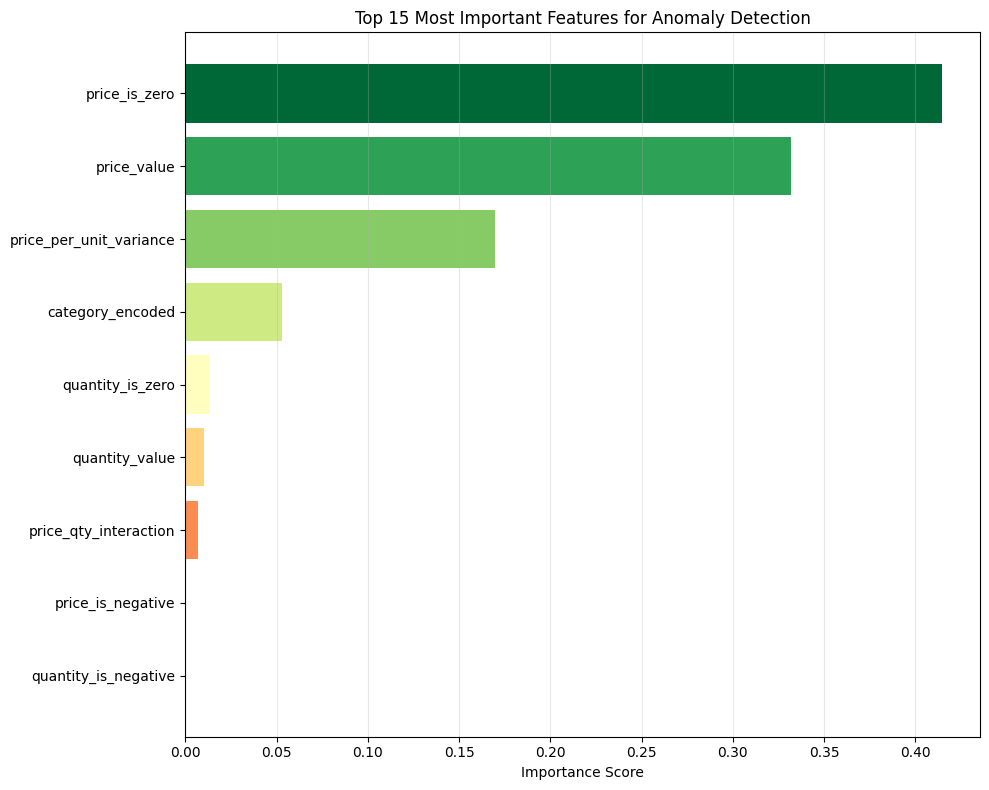


✅ Feature importance analysis complete!


In [18]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'feature': features.columns,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

print("📊 Top 15 Most Important Features:\n")
print(feature_importance.head(15).to_string(index=False))

# Visualize top 15 features
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = feature_importance.head(15)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(top_15)))
ax.barh(range(len(top_15)), top_15['importance'], color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['feature'])
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Most Important Features for Anomaly Detection')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Feature importance analysis complete!")

## Step 8: Confusion Matrix and ROC Curve Visualization

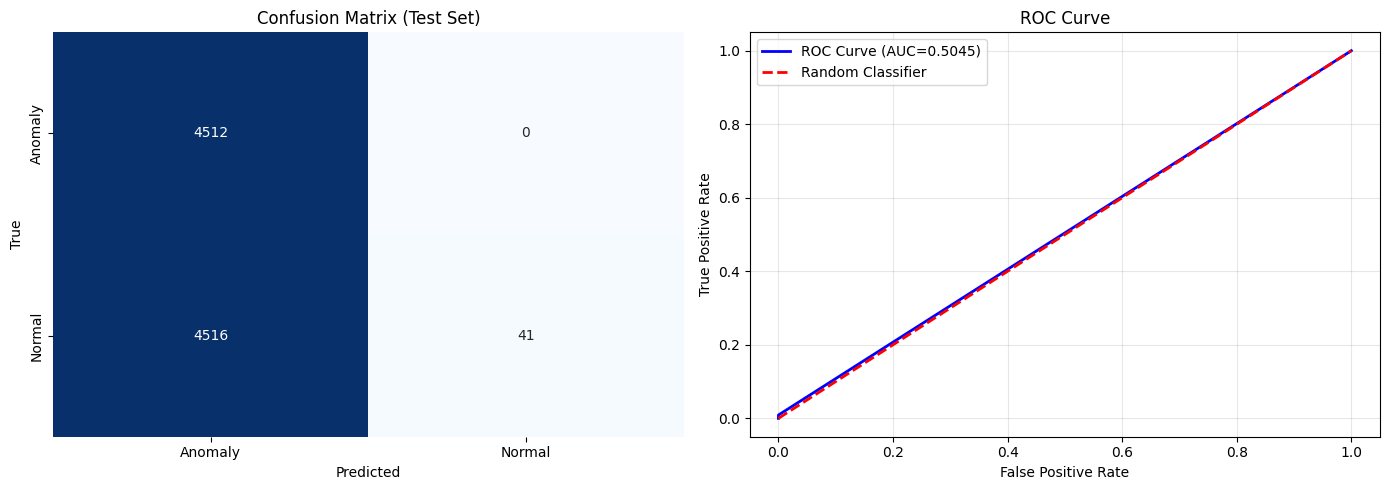

In [19]:
# Visualize confusion matrix and ROC curve
# Handle single-class data (only anomalies)

if len(clf.classes_) == 1:
    # Single class dataset - only show confusion matrix
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Single class confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix - Single Class Only (Anomalies)')
    
    # Only 1 class, so only one label
    class_names = ['Anomaly']
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n⚠️  Single-class data detected (only anomalies)")
    print(f"ROC curve cannot be plotted (needs both classes)")
    
else:
    # Multiple classes - show both confusion matrix and ROC curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')
    ax1.set_title('Confusion Matrix (Test Set)')
    ax1.set_xticklabels(['Anomaly', 'Normal'])
    ax1.set_yticklabels(['Anomaly', 'Normal'])
    
    # ROC curve
    if roc_auc is not None:
        fpr, tpr, _ = roc_curve(y_test, y_test_proba)
        ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC={roc_auc:.4f})')
        ax2.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('ROC Curve')
        ax2.legend()
        ax2.grid(alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'ROC Curve\nNot Available\n(Single Class Data)', 
                ha='center', va='center', fontsize=12)
        ax2.set_title('ROC Curve')
    
    plt.tight_layout()
    plt.show()

## Step 9: Save Model and Encoders

In [20]:
# Create models directory if not exists
os.makedirs('models', exist_ok=True)

print("💾 Saving model and artifacts...\\n")

# Save model
model_path = 'models/supervised_anomaly_model.pkl'
joblib.dump(clf, model_path)
print(f"✅ Model saved: {model_path}")

# Save feature encoders (from trainer)
encoder_path = 'models/feature_encoders.pkl'
joblib.dump(trainer.label_encoders, encoder_path)
print(f"✅ Encoders saved: {encoder_path}")

# Save feature names (from trainer)
feature_names_path = 'models/feature_names.json'
import json
with open(feature_names_path, 'w') as f:
    json.dump(trainer.feature_names, f)
print(f"✅ Feature names saved: {feature_names_path}")

# Calculate metrics
train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

# Save feature importance for reference
feature_importance = pd.DataFrame({
    'feature': trainer.feature_names,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)

importance_path = 'models/feature_importance.csv'
feature_importance.to_csv(importance_path, index=False)
print(f"✅ Feature importance saved: {importance_path}")

print(f"\\n" + "="*70)
print("✅ PHASE 2 MODEL TRAINING COMPLETE")
print("="*70)
print(f"\\nModel Summary:")
print(f"  • Model type: RandomForestClassifier")
print(f"  • n_estimators: 100")
print(f"  • Training accuracy: {train_accuracy:.2%}")
print(f"  • Test accuracy: {test_accuracy:.2%}")
print(f"\\nFiles saved:")
print(f"  ✓ models/supervised_anomaly_model.pkl")
print(f"  ✓ models/feature_encoders.pkl")
print(f"  ✓ models/feature_names.json")
print(f"  ✓ models/feature_importance.csv")
print(f"\\n🚀 Next step: Restart your file watcher to use the model!")
print(f"   The ML detector will automatically load the trained model.")

💾 Saving model and artifacts...\n
✅ Model saved: models/supervised_anomaly_model.pkl
✅ Encoders saved: models/feature_encoders.pkl
✅ Feature names saved: models/feature_names.json
✅ Feature importance saved: models/feature_importance.csv
\n======================================================================
✅ PHASE 2 MODEL TRAINING COMPLETE
\nModel Summary:
  • Model type: RandomForestClassifier
  • n_estimators: 100
  • Training accuracy: 50.25%
  • Test accuracy: 50.20%
\nFiles saved:
  ✓ models/supervised_anomaly_model.pkl
  ✓ models/feature_encoders.pkl
  ✓ models/feature_names.json
  ✓ models/feature_importance.csv
\n🚀 Next step: Restart your file watcher to use the model!
   The ML detector will automatically load the trained model.
